# Библиотеки

In [53]:
from itertools import combinations
from pprint import pprint

import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg

# !pip install -U "scikit-learn==1.1.3" "factor_analyzer==0.4.1"
import statsmodels.stats.stattools as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.api import add_constant

from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

## 10.15 Факторный анализ (библиотека factor_analyzer)

In [2]:
d = pd.read_excel('./data/BAT.xlsx', index_col='Анкета')

In [3]:
d.head(3)

,Престижно,Команда,ПриличнаяЗП,ПрофРост,Карьера,Стабильность,Интересно,КомфортУсловия,РеализСпособностей,ПрофРазвитие,...,СтильУправления,РедкаяПохвалаРуковод,НепониманиеВысшегоРуков,ОбращаюсьРуковПоддержка,РуковОткрытоОбсуждает,ДовериеВысшегоРуков,ЧувствуюПолноцСотруд,ОщущЧастьюКомпании,СвободаМнений,ЦенятвКомпании
Анкета,,,,,,,,,,,,,,,,,,,,,
53,5.0,5.0,5.0,5.0,2.0,5.0,5.0,5.0,3.0,4.0,...,4.0,4.0,4.0,5.0,2.0,5.0,5.0,5.0,2.0,4.0
54,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,...,5.0,2.0,4.0,2.0,4.0,5.0,4.0,5.0,1.0,5.0
55,4.0,5.0,5.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,...,3.0,4.0,5.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0


In [4]:
# 4.1 Размерность (сколько строк и столбцов)
d.shape

(510, 33)

In [5]:
# 4.2 Тип данных и быстрый взгляд на шкалы/уникальные значения (заметить “особый” вопрос на 6 категорий)
d.describe(include="all")

,Престижно,Команда,ПриличнаяЗП,ПрофРост,Карьера,Стабильность,Интересно,КомфортУсловия,РеализСпособностей,ПрофРазвитие,...,СтильУправления,РедкаяПохвалаРуковод,НепониманиеВысшегоРуков,ОбращаюсьРуковПоддержка,РуковОткрытоОбсуждает,ДовериеВысшегоРуков,ЧувствуюПолноцСотруд,ОщущЧастьюКомпании,СвободаМнений,ЦенятвКомпании
count,483.000000,484.000000,487.000000,459.000000,453.000000,489.000000,463.000000,484.000000,493.000000,489.000000,...,485.000000,486.000000,490.000000,493.000000,494.000000,489.000000,480.000000,473.000000,498.000000,495.000000
mean,4.459627,3.991736,4.445585,3.884532,3.311258,4.200409,4.021598,4.150826,3.791075,3.781186,...,3.921649,2.685185,3.079592,4.221095,3.469636,3.881391,4.541667,4.289641,3.178715,3.531313
std,0.794121,1.152876,0.759451,1.238819,1.344534,1.071578,1.006240,1.023522,1.134708,1.082259,...,0.998990,1.361347,1.293286,1.135979,1.360888,1.068476,0.800791,0.908201,1.285341,1.042871
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,3.000000,4.000000,3.000000,2.000000,4.000000,3.000000,4.000000,3.000000,3.000000,...,3.000000,1.000000,2.000000,4.000000,2.000000,3.000000,4.000000,4.000000,2.000000,3.000000
50%,5.000000,4.000000,5.000000,4.000000,3.000000,5.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,2.000000,3.000000,5.000000,4.000000,4.000000,5.000000,5.000000,3.000000,4.000000
75%,5.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [6]:
d.nunique().sort_values()

Престижно                    5
ОщущЧастьюКомпании           5
ЧувствуюПолноцСотруд         5
ДовериеВысшегоРуков          5
РуковОткрытоОбсуждает        5
ОбращаюсьРуковПоддержка      5
НепониманиеВысшегоРуков      5
РедкаяПохвалаРуковод         5
СтильУправления              5
Руководитель                 5
ЕдинаяКоманда                5
ОщущениеДискомф              5
НеформОбщение                5
ЗПАдеквРынку                 5
СвободаМнений                5
ПринципыЗП                   5
Зарплата                     5
Команда                      5
ПриличнаяЗП                  5
ПрофРост                     5
Карьера                      5
Стабильность                 5
Интересно                    5
ДопЛьготы                    5
КомфортУсловия               5
ПрофРазвитие                 5
ВозмКарьерРоста              5
ЛичностнРост                 5
КомфУслТруда                 5
ЭффективностьРаботыОтдела    5
РеализСпособностей           5
ЦенятвКомпании               5
РешенияР

In [7]:
# 4.3 Пропуски (если есть, заполнить модой)
d.isna().sum().sort_values(ascending=False)

ВозмКарьерРоста              63
ЭффективностьРаботыОтдела    58
Карьера                      57
ПрофРост                     51
Интересно                    47
КомфУслТруда                 42
ОщущЧастьюКомпании           37
ЧувствуюПолноцСотруд         30
ОщущениеДискомф              28
Престижно                    27
КомфортУсловия               26
Команда                      26
ЗПАдеквРынку                 25
СтильУправления              25
РедкаяПохвалаРуковод         24
ПриличнаяЗП                  23
ПрофРазвитие                 21
ДовериеВысшегоРуков          21
Стабильность                 21
НепониманиеВысшегоРуков      20
ЕдинаяКоманда                20
НеформОбщение                19
ЛичностнРост                 18
РеализСпособностей           17
ОбращаюсьРуковПоддержка      17
РешенияРуковод               16
РуковОткрытоОбсуждает        16
ЦенятвКомпании               15
ПринципыЗП                   13
СвободаМнений                12
Руководитель                  8
ДопЛьгот

In [8]:
d = d.fillna(d.mode().iloc[0])

array([[<Axes: xlabel='Престижно', ylabel='Престижно'>,
        <Axes: xlabel='Команда', ylabel='Престижно'>,
        <Axes: xlabel='ПриличнаяЗП', ylabel='Престижно'>,
        <Axes: xlabel='ПрофРост', ylabel='Престижно'>,
        <Axes: xlabel='Карьера', ylabel='Престижно'>],
       [<Axes: xlabel='Престижно', ylabel='Команда'>,
        <Axes: xlabel='Команда', ylabel='Команда'>,
        <Axes: xlabel='ПриличнаяЗП', ylabel='Команда'>,
        <Axes: xlabel='ПрофРост', ylabel='Команда'>,
        <Axes: xlabel='Карьера', ylabel='Команда'>],
       [<Axes: xlabel='Престижно', ylabel='ПриличнаяЗП'>,
        <Axes: xlabel='Команда', ylabel='ПриличнаяЗП'>,
        <Axes: xlabel='ПриличнаяЗП', ylabel='ПриличнаяЗП'>,
        <Axes: xlabel='ПрофРост', ylabel='ПриличнаяЗП'>,
        <Axes: xlabel='Карьера', ylabel='ПриличнаяЗП'>],
       [<Axes: xlabel='Престижно', ylabel='ПрофРост'>,
        <Axes: xlabel='Команда', ylabel='ПрофРост'>,
        <Axes: xlabel='ПриличнаяЗП', ylabel='ПрофРост'>,
 

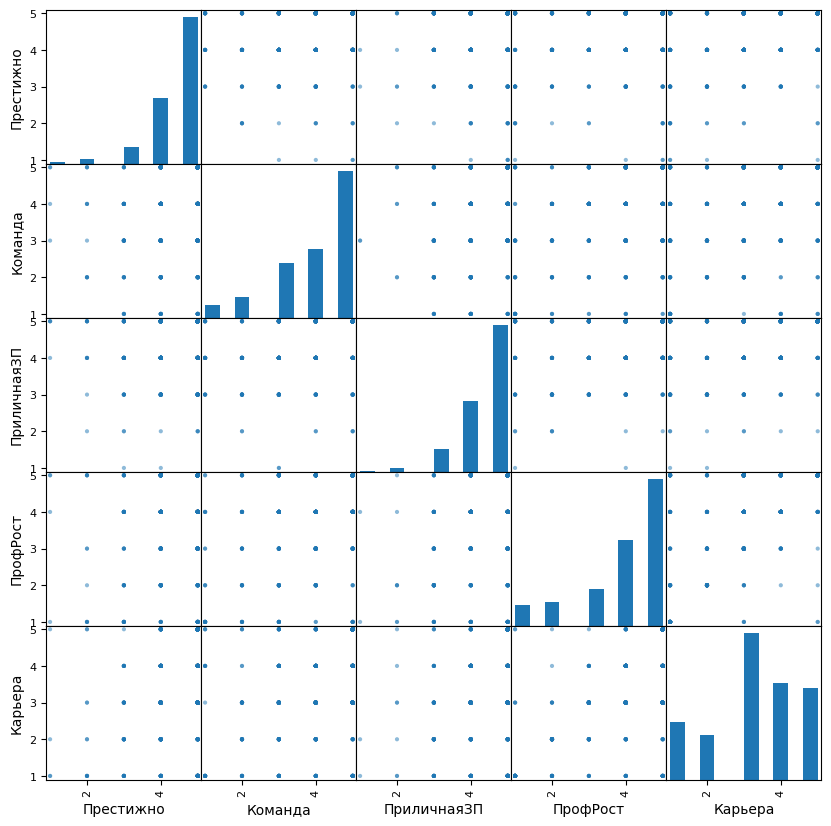

In [9]:
# 4.4 Линейность на диаграммах рассеяния (5 любых столбцов, подставь свои названия)
cols5 = d.columns[:5]
pd.plotting.scatter_matrix(d[cols5], figsize=(10,10))

<Axes: >

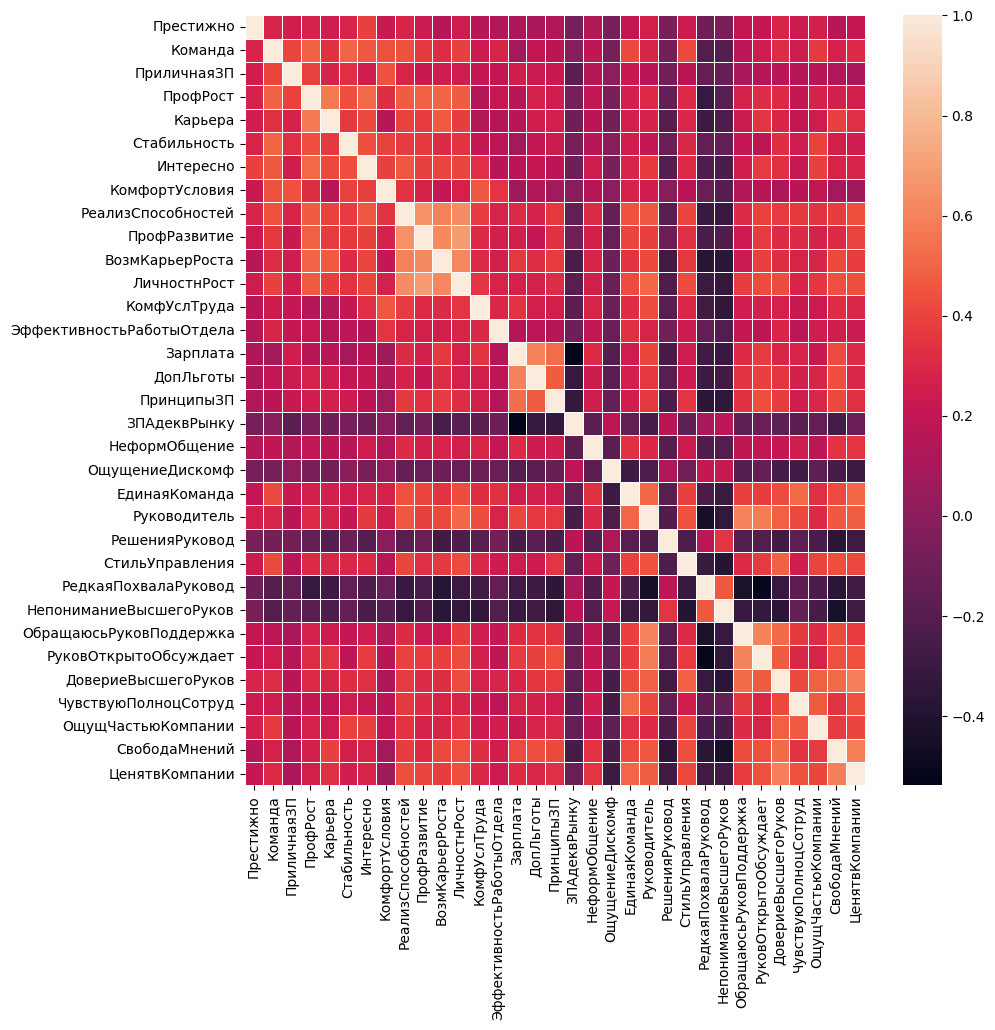

In [52]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(d.corr(), linewidths=.5, ax=ax)

In [10]:
# 4.5 Многомерная нормальность (по Генри-Зинклеру в pingouin)
pg.multivariate_normality(d)

HZResults(hz=1.0633770865882528, pval=0.0, normal=False)

In [11]:
# 4.6 Корреляции и поиск мультиколлинеарности (Spearman), сохранить в Excel и потом открыть глазами
corr_s = d.corr(method="spearman")
# corr_s.to_excel("corr_spearman.xlsx")
corr_s

,Престижно,Команда,ПриличнаяЗП,ПрофРост,Карьера,Стабильность,Интересно,КомфортУсловия,РеализСпособностей,ПрофРазвитие,...,СтильУправления,РедкаяПохвалаРуковод,НепониманиеВысшегоРуков,ОбращаюсьРуковПоддержка,РуковОткрытоОбсуждает,ДовериеВысшегоРуков,ЧувствуюПолноцСотруд,ОщущЧастьюКомпании,СвободаМнений,ЦенятвКомпании
Престижно,1.000000,0.356329,0.309844,0.284298,0.226665,0.325251,0.386658,0.293472,0.269010,0.235558,...,0.201116,-0.092661,-0.048015,0.148488,0.172965,0.229342,0.240640,0.207844,0.127506,0.192677
Команда,0.356329,1.000000,0.463990,0.504312,0.336984,0.525155,0.495125,0.466301,0.399318,0.337251,...,0.389552,-0.182546,-0.172802,0.173880,0.234259,0.304294,0.190816,0.312945,0.233923,0.289488
ПриличнаяЗП,0.309844,0.463990,1.000000,0.437435,0.263590,0.405317,0.318589,0.519006,0.291127,0.243691,...,0.177544,-0.135129,-0.137025,0.103611,0.167740,0.171798,0.142372,0.174983,0.107581,0.132802
ПрофРост,0.284298,0.504312,0.437435,1.000000,0.509278,0.455940,0.499898,0.384682,0.418407,0.428906,...,0.270618,-0.283187,-0.169799,0.241829,0.287880,0.259594,0.152407,0.244527,0.193621,0.209334
Карьера,0.226665,0.336984,0.263590,0.509278,1.000000,0.331352,0.377907,0.183791,0.380750,0.353924,...,0.290570,-0.290066,-0.222636,0.210900,0.323201,0.295520,0.198437,0.254824,0.376216,0.327903
Стабильность,0.325251,0.525155,0.405317,0.455940,0.331352,1.000000,0.441207,0.468608,0.333973,0.346337,...,0.257037,-0.140544,-0.099017,0.164944,0.163917,0.307270,0.213451,0.327418,0.206226,0.224935
Интересно,0.386658,0.495125,0.318589,0.499898,0.377907,0.441207,1.000000,0.437912,0.441174,0.393336,...,0.291431,-0.231839,-0.235076,0.227533,0.351684,0.322233,0.178600,0.347379,0.259383,0.265094
КомфортУсловия,0.293472,0.466301,0.519006,0.384682,0.183791,0.468608,0.437912,1.000000,0.332058,0.279209,...,0.181853,-0.113414,-0.152103,0.140473,0.153280,0.120765,0.135632,0.169332,0.069759,0.058152
РеализСпособностей,0.269010,0.399318,0.291127,0.418407,0.380750,0.333973,0.441174,0.332058,1.000000,0.620561,...,0.385536,-0.314802,-0.311075,0.281166,0.378707,0.320714,0.312932,0.295276,0.337752,0.384483
ПрофРазвитие,0.235558,0.337251,0.243691,0.428906,0.353924,0.346337,0.393336,0.279209,0.620561,1.000000,...,0.317143,-0.249433,-0.225503,0.222983,0.388171,0.309706,0.255334,0.262373,0.281845,0.346665


In [12]:
# 4.7 Автоматический поиск пар с r>0.9 (чтобы понимать что выкидывать)
upper = corr_s.where(np.triu(np.ones(corr_s.shape), k=1).astype(bool))
high_pairs = upper.stack().sort_values(ascending=False)

In [13]:
high_pairs[high_pairs.abs() > 0.9]

Series([], dtype: float64)

In [14]:
# 4.8 Выбросы “в целом” через robust корреляции Shepherd (тяжелая операция, но по заданию)
shep = pg.pairwise_corr(d, method="shepherd")
shep.head()

,X,Y,method,alternative,n,outliers,r,CI95%,p-unc,power
0,Престижно,Команда,shepherd,two-sided,510,36.0,0.369405,"[0.29, 0.44]",8.999989e-17,1.000000
1,Престижно,ПриличнаяЗП,shepherd,two-sided,510,29.0,0.286845,"[0.2, 0.37]",1.457007e-10,0.999997
2,Престижно,ПрофРост,shepherd,two-sided,510,44.0,0.286782,"[0.2, 0.37]",2.842868e-10,0.999994
3,Престижно,Карьера,shepherd,two-sided,510,16.0,0.208133,"[0.12, 0.29]",3.079310e-06,0.996782
4,Престижно,Стабильность,shepherd,two-sided,510,41.0,0.337307,"[0.25, 0.42]",6.074273e-14,1.000000


In [15]:
# 4.9 КМО и Бартлетт (главное для ответа про применимость)
kmo_all, kmo_model = calculate_kmo(d)
kmo_model

0.92084115273178

In [16]:
chi2, p_bart = calculate_bartlett_sphericity(d)
chi2, p_bart

(7516.981889556129, 0.0)

In [17]:
high_pairs[high_pairs>0.9]

Series([], dtype: float64)

In [18]:
# Если есть пары с r>0.9, удалить одну переменную из каждой такой пары (пример: удалить второй столбец в паре)
# Если high_pairs пустой, этот шаг пропускаешь.
to_drop = []
for (a, b), val in high_pairs.items():
    if abs(val) > 0.9:
        to_drop.append(b)
        to_drop = sorted(set(to_drop))
        to_drop

In [19]:
# d = d.drop(columns=to_drop)
to_drop

[]

In [20]:
# Определить оптимальное число факторов (Kaiser: eigenvalue >= 1) без вращения
fa = FactorAnalyzer(n_factors=d.shape[1], rotation=None, method="minres")

In [21]:
fa.fit(d)

FactorAnalyzer(n_factors=33, rotation=None, rotation_kwargs={})

In [22]:
eigs, _ = fa.get_eigenvalues()
eigs

array([10.39869757,  2.56826043,  1.6235163 ,  1.45735604,  1.29982989,
        1.26630817,  1.14344743,  0.95466859,  0.92590429,  0.82150443,
        0.79247992,  0.77343936,  0.71966415,  0.66993985,  0.65245419,
        0.59073691,  0.58014588,  0.52971864,  0.501574  ,  0.46735898,
        0.46251679,  0.40740025,  0.38350592,  0.36566823,  0.3537179 ,
        0.33891519,  0.33223553,  0.32144108,  0.30720085,  0.28103481,
        0.26030655,  0.23027488,  0.21877702])

In [23]:
n_opt = (eigs >= 1).sum()
n_opt

7

In [24]:
# Обучить финальную модель на 7 факторах с varimax (по заданию 7)
fa7 = FactorAnalyzer(n_factors=7, rotation="varimax", method="minres")
fa7.fit(d)

FactorAnalyzer(n_factors=7, rotation='varimax', rotation_kwargs={})

In [25]:
# Собственные значения и объясненная дисперсия по факторам, собрать EV
e, v, cv = fa7.get_factor_variance()
EV = pd.DataFrame({"e": e, "v": v, "cv": cv})
EV

,e,v,cv
0,3.378160,0.102368,0.102368
1,3.104476,0.094075,0.196444
2,2.533348,0.076768,0.273212
3,2.279299,0.069070,0.342281
4,2.136324,0.064737,0.407018
5,1.577776,0.047811,0.454830
6,1.550732,0.046992,0.501822


In [26]:
EV["cv"].iloc[-1]

0.5018216823961478

In [27]:
# Общности (communalities), собрать C и посмотреть что <0.2
C = pd.Series(fa7.get_communalities(), index=d.columns).sort_values()
C

ОщущениеДискомф              0.162097
НеформОбщение                0.223418
Престижно                    0.231200
РешенияРуковод               0.231873
ЭффективностьРаботыОтдела    0.232967
ЗПАдеквРынку                 0.332901
ПриличнаяЗП                  0.379212
СтильУправления              0.397566
ОщущЧастьюКомпании           0.432818
ПринципыЗП                   0.440984
Интересно                    0.447946
КомфУслТруда                 0.451617
Карьера                      0.454672
Стабильность                 0.460245
РедкаяПохвалаРуковод         0.465291
ДопЛьготы                    0.467485
ЧувствуюПолноцСотруд         0.470070
ЕдинаяКоманда                0.526260
Команда                      0.533467
НепониманиеВысшегоРуков      0.577083
СвободаМнений                0.582568
ЦенятвКомпании               0.593428
ДовериеВысшегоРуков          0.597801
ОбращаюсьРуковПоддержка      0.618230
РеализСпособностей           0.628305
ПрофРост                     0.631321
ЛичностнРост

In [28]:
# Нагрузки, собрать L и оставить только |loading|>=0.4, убрать пустые строки
L = pd.DataFrame(fa7.loadings_, index=d.columns)
L_filtered = L.where(L.abs() >= 0.4).dropna(how="all")
L_filtered

,0,1,2,3,4,5,6
Команда,0.621319,NaN,NaN,NaN,NaN,NaN,NaN
ПриличнаяЗП,0.489445,NaN,NaN,NaN,NaN,NaN,NaN
ПрофРост,0.663537,NaN,NaN,NaN,NaN,NaN,NaN
Карьера,0.504593,NaN,NaN,NaN,NaN,NaN,NaN
Стабильность,0.628427,NaN,NaN,NaN,NaN,NaN,NaN
Интересно,0.549599,NaN,NaN,NaN,NaN,NaN,NaN
КомфортУсловия,0.452024,NaN,NaN,NaN,NaN,NaN,0.756154
РеализСпособностей,NaN,NaN,0.576828,NaN,NaN,NaN,NaN
ПрофРазвитие,NaN,NaN,0.751524,NaN,NaN,NaN,NaN
ВозмКарьерРоста,NaN,NaN,0.643818,NaN,NaN,NaN,NaN


In [65]:
EV

,e,v,cv
0,3.378160,0.102368,0.102368
1,3.104476,0.094075,0.196444
2,2.533348,0.076768,0.273212
3,2.279299,0.069070,0.342281
4,2.136324,0.064737,0.407018
5,1.577776,0.047811,0.454830
6,1.550732,0.046992,0.501822


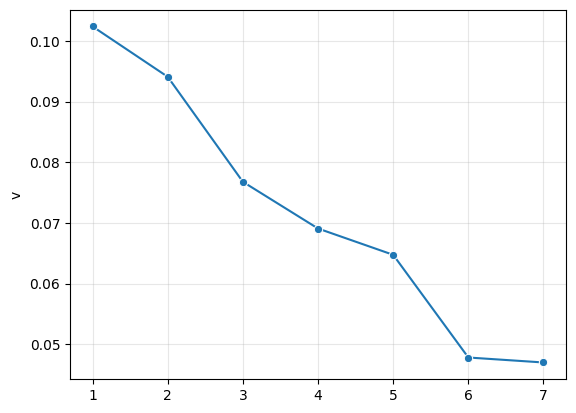

In [71]:
sns.lineplot(x=range(1, len(EV['e'])+1), y=EV['v'], marker='o').grid(True, alpha=0.3)

In [75]:
l = pd.DataFrame(fa.loadings_, index=d.columns, columns=[f'F{i+1}' for i in range (fa.loadings_. shape[1])])

<Axes: >

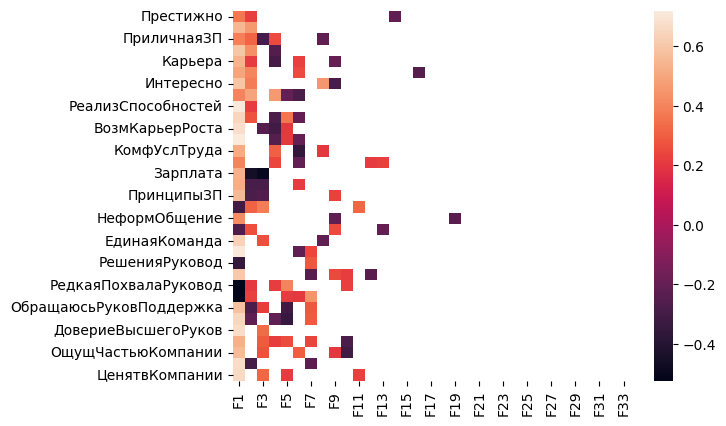

In [80]:
sns.heatmap(l[l.abs()>0.2])